# H-Bond Frequency Clustering Analysis

**What this notebook does:**
Starting from per-simulation interaction CSV files (binary H-bond presence per frame),
this notebook:
1. Extracts H-bond frequencies in a **transition-state window** around each simulation's
   phase boundary, separated into **Phase 1** and **Phase 2**
2. Builds a frequency table (bonds × simulation-phases) and saves it to CSV
3. Clusters simulation-phases by frequency similarity — **dendrogram based on raw
   frequencies** and **dendrogram based on high-variance bonds** (Δfreq ≥ threshold)
4. Performs **PCA** on per-frame interaction data (loaded from phase CSVs)
5. Trains a **Decision Tree** to discriminate simulation-phases by bond frequencies
6. Runs an optional **inter-chain bond analysis**

**Sections:**
1. Imports
2. Configuration (paths, phase limits, simulation list)
3. Helper functions
4. Build frequency table from transition-state windows
5. Plot dendrograms (raw and high-variance)
6. PCA on per-frame data
7. Decision Tree
8. Inter-chain analysis


In [3]:
# 1. Imports
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 2. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'

INTERACTION_FILES = ['res_V12.csv', 'res_V7.csv']
SIMULATION_NAMES  = ['V12', 'V7']

# Phase boundary: last frame of Phase 1 for each simulation
PHASE_LIMIT_DICO = {
    'V7': 198, 'V8': 180, 'V21': 155,
    'V12': 35, 'V11': 1000, 'V1': 517,
}

# Transition-state window (±FRAME_RANGE frames around phase boundary)
FRAME_RANGE = 35

# Minimum |Δfreq| (%) to consider a bond "high-variance"
MIN_DELTA_PCT = 25

# Desired column order in the final frequency table
PHASES_LIST_ORDERED = ['V12_ph1', 'V12_ph2', 'V7_ph1', 'V7_ph2']

os.chdir(ROOTDIR)

In [5]:
# 3. Helper functions

def find_hbonds(df: pd.DataFrame) -> list:
    """Return column names that contain 'hb' (hydrogen bond columns)."""
    return [c for c in df.columns if 'hb' in c]


def get_residue_numbers(bond_name: str):
    """Extract the first two integers from a bond column name."""
    nums = [int(x) for x in re.findall(r'\d+', bond_name)]
    return (nums[0], nums[1]) if len(nums) >= 2 else (None, None)


def classify_chain(resnum) -> str:
    """Return 'A', 'B', or None based on residue number (1–99 → A, 100–198 → B)."""
    if resnum is None: return None
    if 1 <= resnum <= 99:  return 'A'
    if 100 <= resnum <= 198: return 'B'
    return None


def is_interchain(bond_name: str) -> bool:
    """True if the bond connects chain A and chain B residues."""
    r1, r2 = get_residue_numbers(bond_name)
    c1, c2 = classify_chain(r1), classify_chain(r2)
    return c1 != c2 and None not in (c1, c2)


def high_variance_bonds(freq_table: pd.DataFrame,
                        min_delta: float = MIN_DELTA_PCT,
                        top_n: int = None) -> pd.DataFrame:
    """
    Keep bonds whose frequency changes by >= min_delta % between ph1 and ph2
    in at least one simulation.
    """
    sim_names = list({c.rsplit('_', 1)[0] for c in freq_table.columns})
    max_delta = pd.Series(0.0, index=freq_table.index)
    for sim in sim_names:
        ph1, ph2 = f'{sim}_ph1', f'{sim}_ph2'
        if ph1 in freq_table.columns and ph2 in freq_table.columns:
            delta = (freq_table[ph2] - freq_table[ph1]).abs()
            max_delta = max_delta.combine(delta, max)
    mask   = max_delta >= min_delta
    result = freq_table[mask]
    if top_n is not None:
        result = result.loc[max_delta[mask].nlargest(top_n).index]
    return result

In [6]:
# 4. Build frequency table from transition-state windows

# 4.1. Define frame windows
selected_frames_dico = {
    sim: range(lim - FRAME_RANGE, lim + FRAME_RANGE + 1)
    for sim, lim in PHASE_LIMIT_DICO.items()
}

all_phase_frequencies = {}

for i, sim_file in enumerate(INTERACTION_FILES):
    sim = SIMULATION_NAMES[i]
    df_full  = pd.read_csv(sim_file)

    # Slice to transition window
    valid_idx = [ix for ix in df_full.index if ix in selected_frames_dico.get(sim, [])]
    df_ts     = df_full.loc[valid_idx]

    lim = PHASE_LIMIT_DICO.get(sim)
    ph1_idx = df_ts.index[df_ts.index <= lim]
    ph2_idx = df_ts.index[df_ts.index >  lim]
    df_ph1  = df_ts.loc[ph1_idx] if not ph1_idx.empty else pd.DataFrame(columns=df_ts.columns)
    df_ph2  = df_ts.loc[ph2_idx] if not ph2_idx.empty else pd.DataFrame(columns=df_ts.columns)

    hbonds = find_hbonds(df_ts)

    ph1_freqs, ph2_freqs = {}, {}
    for hb in hbonds:
        n1, n2 = len(df_ph1), len(df_ph2)
        ph1_freqs[hb] = (df_ph1[hb] > 0).sum() / n1 * 100 if n1 > 0 else 0.0
        ph2_freqs[hb] = (df_ph2[hb] > 0).sum() / n2 * 100 if n2 > 0 else 0.0

    all_phase_frequencies[f'{sim}_ph1'] = ph1_freqs
    all_phase_frequencies[f'{sim}_ph2'] = ph2_freqs

freq_table = pd.DataFrame(all_phase_frequencies)
existing = [c for c in PHASES_LIST_ORDERED if c in freq_table.columns]
freq_table = freq_table[existing]
freq_table = freq_table[freq_table.sum(axis=1) > 0]

print(f'Frequency table: {freq_table.shape[0]} bonds × {freq_table.shape[1]} phases')
freq_table.head()

Frequency table: 692 bonds × 4 phases


,V12_ph1,V12_ph2,V7_ph1,V7_ph2
hbbb_ASN_40_O_TYR_42_N,22.222222,25.714286,8.333333,34.285714
hbbb_GLN_18_N_GLY_17_N,11.111111,14.285714,5.555556,14.285714
hbsb_MET_76_O_THR_77_OG1,0.000000,0.000000,0.000000,2.857143
hbbb_ILE_82_N_THR_80_O,33.333333,88.571429,5.555556,2.857143
hbsb_GLY_138_O_TYR_158_OH,5.555556,65.714286,66.666667,40.000000


In [7]:
# 4.2. Save frequency table to CSV
freq_table.to_csv(
    os.path.join(OUTPUT_DIR, 'interactions_freq_table.csv'),
    index=True, header=True, decimal='.', float_format='%.5f'
)
print('Saved to interactions_freq_table.csv')

Saved to interactions_freq_table.csv


Bonds with ≥ 80% frequency: 132


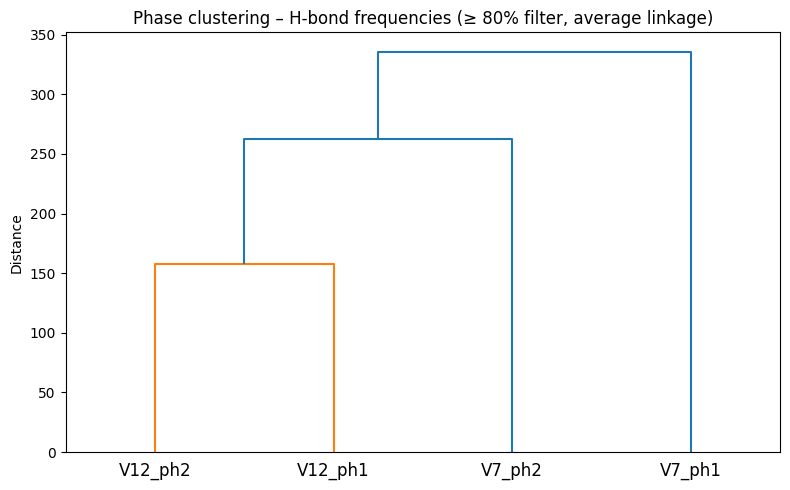

In [8]:
# 5.1. Dendrogram — raw H-bond frequencies (≥ 80 % in at least one phase)
filtered_freq_table = freq_table[(freq_table > 80).any(axis=1)]
print(f'Bonds with ≥ 80% frequency: {len(filtered_freq_table)}')

if len(filtered_freq_table) >= 2:
    X_phases = filtered_freq_table.T
    linked   = linkage(X_phases, method='average')
    fig, ax = plt.subplots(figsize=(8, 5))
    dendrogram(linked, orientation='top', labels=X_phases.index.tolist(),
               distance_sort='descending', ax=ax)
    ax.set_title('Phase clustering – H-bond frequencies (≥ 80% filter, average linkage)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'dendrogram_phases_raw.png'), dpi=300)
    plt.show()
else:
    print('[WARN] Too few bonds for dendrogram.')

Bonds retained after |Δfreq| ≥ 25% filter: 67


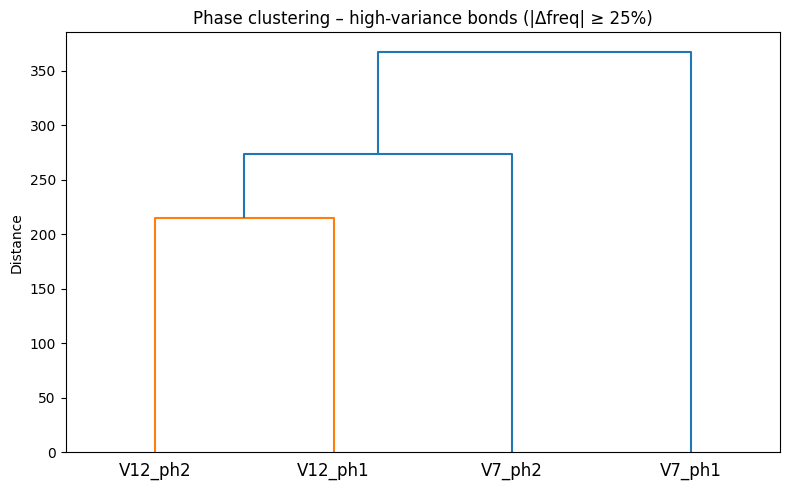

In [9]:
# 5.2. Dendrogram — high-variance bonds (|Δfreq| ≥ MIN_DELTA_PCT)
hv_freq = high_variance_bonds(freq_table, min_delta=MIN_DELTA_PCT)
print(f'Bonds retained after |Δfreq| ≥ {MIN_DELTA_PCT}% filter: {len(hv_freq)}')

if len(hv_freq) >= 2:
    X_phases = hv_freq.T
    linked   = linkage(X_phases, method='average')
    fig, ax = plt.subplots(figsize=(8, 5))
    dendrogram(linked, orientation='top', labels=X_phases.index.tolist(),
               distance_sort='descending', ax=ax)
    ax.set_title(f'Phase clustering – high-variance bonds (|Δfreq| ≥ {MIN_DELTA_PCT}%)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'dendrogram_phases_hv.png'), dpi=300)
    plt.show()
else:
    print('[WARN] Too few high-variance bonds.')

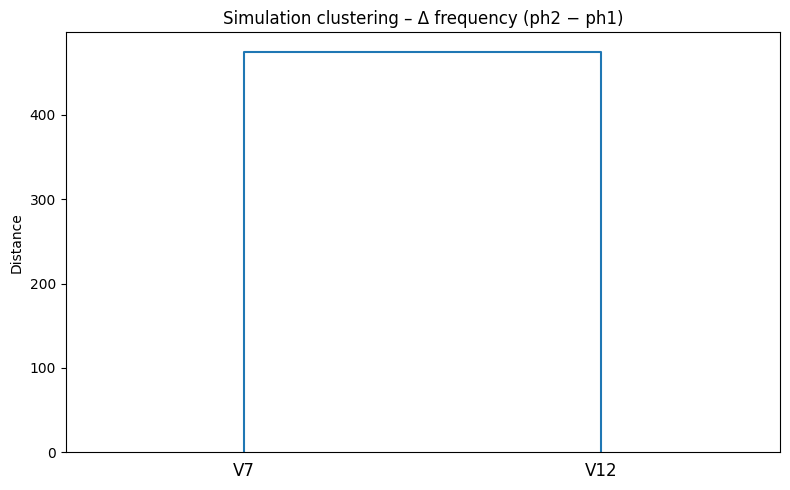

In [10]:
# 5.3. Dendrogram — Δ-frequency clustering (ph2 − ph1 per simulation)
delta_rows = {}
for sim in SIMULATION_NAMES:
    ph1, ph2 = f'{sim}_ph1', f'{sim}_ph2'
    if ph1 in freq_table.columns and ph2 in freq_table.columns:
        delta_rows[sim] = freq_table[ph2] - freq_table[ph1]

delta_df = pd.DataFrame(delta_rows).T
delta_df = delta_df.loc[:, (delta_df != 0).any()]

if len(delta_df) >= 2:
    linked_delta = linkage(delta_df, method='ward')
    fig, ax = plt.subplots(figsize=(8, 5))
    dendrogram(linked_delta, orientation='top', labels=delta_df.index.tolist(),
               distance_sort='descending', ax=ax)
    ax.set_title('Simulation clustering – Δ frequency (ph2 − ph1)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'dendrogram_delta_freq.png'), dpi=300)
    plt.show()


Explained variance by component:
  PC1: 4.2%  (cumulative: 4.2%)
  PC2: 2.1%  (cumulative: 6.3%)
  PC3: 2.0%  (cumulative: 8.3%)
  PC4: 1.8%  (cumulative: 10.1%)


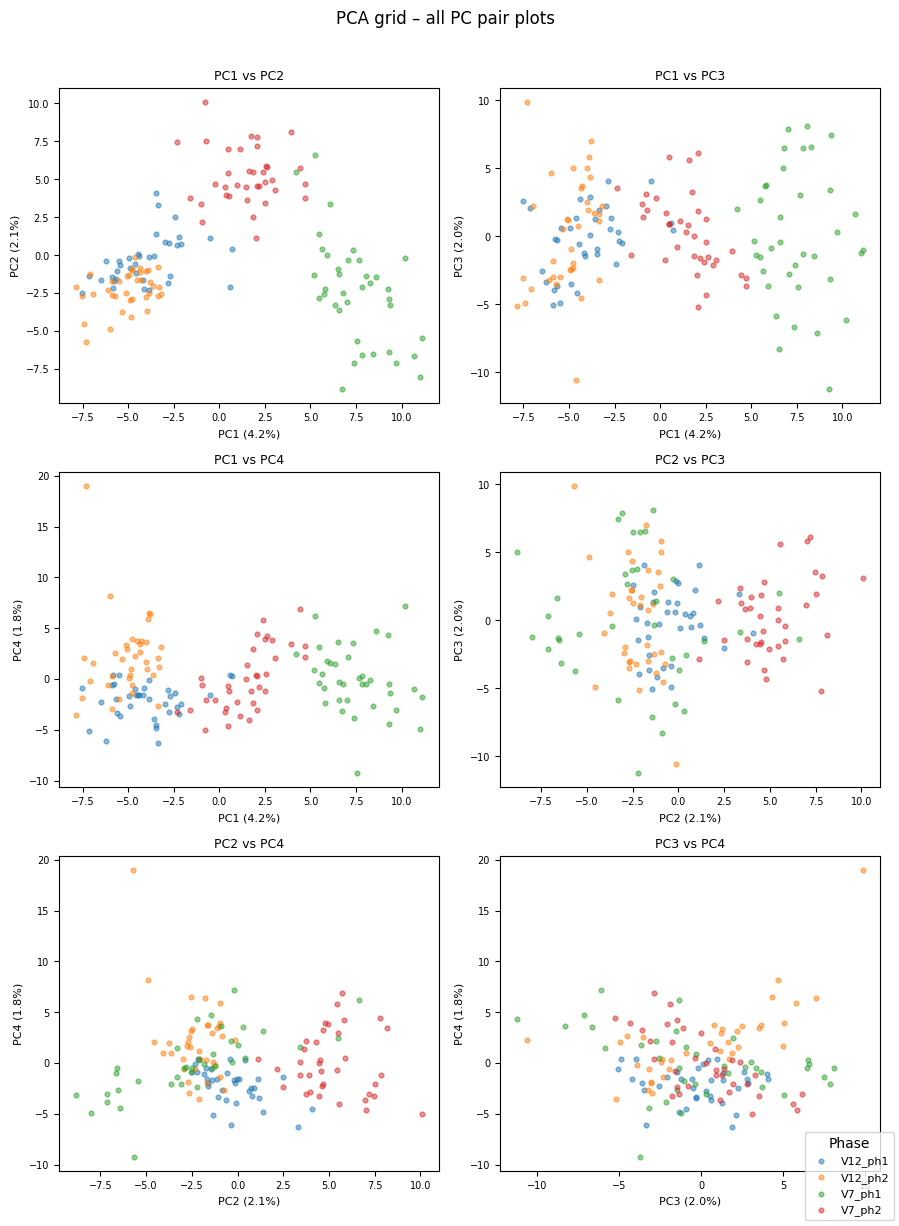

IndexError: index 4 is out of bounds for axis 0 with size 4

In [ ]:
# 6. PCA on per-frame interaction data
# Expects phase CSVs named e.g. 'V12_ph1_interactions.csv' in OUTPUT_DIR

# Fit up to N_PCS components, then display every pair (PC1/2, PC1/3, PC2/3 …)
# as a grid of scatter plots.  Higher PCs sometimes capture phase separation
# better than PC1/PC2 when simulation identity dominates the first axes.

PHASE_CSV_MAP = {
    'V12_ph1': 'V12_ph1_interactions.csv',
    'V12_ph2': 'V12_ph2_interactions.csv',
    'V7_ph1':  'V7_ph1_interactions.csv',
    'V7_ph2':  'V7_ph2_interactions.csv',
}
N_PCS = 4

os.chdir(OUTPUT_DIR)
df_pca_input = pd.DataFrame()
for label, fname in PHASE_CSV_MAP.items():
    if not os.path.exists(fname):
        print(f'[WARN] {fname} not found — skipping.')
        continue
    df_tmp  = pd.read_csv(fname)
    hb_cols = find_hbonds(df_tmp)
    df_tmp  = df_tmp[hb_cols].copy()
    df_tmp['label'] = label
    df_pca_input = pd.concat([df_pca_input, df_tmp], ignore_index=True)

if not df_pca_input.empty:
    df_pca_input = df_pca_input.loc[
        (df_pca_input.drop('label', axis=1) != 0).any(axis=1)]
    zero_cols = [c for c in df_pca_input.columns
                if c != 'label' and df_pca_input[c].sum() == 0]
    df_pca_input.drop(columns=zero_cols, inplace=True)

    X_pca  = df_pca_input.drop('label', axis=1)
    y_pca  = df_pca_input['label'].reset_index(drop=True)
    n_comp = min(N_PCS, X_pca.shape[1], X_pca.shape[0])

    X_scaled   = StandardScaler().fit_transform(X_pca)
    pca        = PCA(n_components=n_comp)
    components = pca.fit_transform(X_scaled)
    var_expl   = pca.explained_variance_ratio_ * 100

    pc_cols = [f'PC{i+1}' for i in range(n_comp)]
    pca_df  = pd.DataFrame(components, columns=pc_cols)
    pca_df['label'] = y_pca.values
    pca_df['simulation'] = pca_df['label'].str.split('_').str[0]
    pca_df['phase']      = pca_df['label'].str.split('_').str[1]

    print(f"\nExplained variance by component:")
    for i, v in enumerate(var_expl):
        print(f"  PC{i+1}: {v:.1f}%  (cumulative: {var_expl[:i+1].sum():.1f}%)")

    # --- Individual interactive scatter: PC1 vs PC2 (quick reference) ---------
    fig = px.scatter(pca_df, x='PC1', y='PC2', color='label',
                    title=f'PCA – PC1 vs PC2  '
                        f'({var_expl[0]:.1f}% + {var_expl[1]:.1f}%)',
                    labels={'PC1': f'PC1 ({var_expl[0]:.1f}%)',
                            'PC2': f'PC2 ({var_expl[1]:.1f}%)'})
    fig.update_traces(marker=dict(size=6, opacity=0.6))
    fig.write_html(os.path.join(OUTPUT_DIR, 'pca_PC1_PC2.html'))
    fig.show()

    # --- Grid of all PC pair plots (static, saved as PNG) ---------------------
    from itertools import combinations
    pairs = list(combinations(pc_cols, 2))
    ncols = 2
    nrows = -(-len(pairs) // ncols)   # ceiling division

    label_colors = {lbl: c for lbl, c in zip(
        pca_df['label'].unique(),
        plt.cm.tab10.colors[:len(pca_df['label'].unique())])}

    fig, axes = plt.subplots(nrows, ncols,
                            figsize=(ncols * 4.5, nrows * 4),
                            squeeze=False)
    for ax_idx, (pcx, pcy) in enumerate(pairs):
        row, col = divmod(ax_idx, ncols)
        ax = axes[row][col]
        for lbl, grp in pca_df.groupby('label'):
            ax.scatter(grp[pcx], grp[pcy],
                    label=lbl, s=12, alpha=0.5,
                    color=label_colors[lbl])
        xi, yi = int(pcx[2:]) - 1, int(pcy[2:]) - 1
        ax.set_xlabel(f'{pcx} ({var_expl[xi]:.1f}%)', fontsize=8)
        ax.set_ylabel(f'{pcy} ({var_expl[yi]:.1f}%)', fontsize=8)
        ax.set_title(f'{pcx} vs {pcy}', fontsize=9)
        ax.tick_params(labelsize=7)

    # Hide unused axes
    for ax_idx in range(len(pairs), nrows * ncols):
        row, col = divmod(ax_idx, ncols)
        axes[row][col].set_visible(False)

    # Single shared legend
    handles, labels_leg = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='lower right',
            fontsize=8, title='Phase', framealpha=0.8)
    fig.suptitle('PCA grid – all PC pair plots', fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'pca_grid.png'), dpi=300,
                bbox_inches='tight')
    plt.show()

    # --- Per-PC interactive plots (coloured by phase only, for clarity) --------
    for pcx, pcy in [(f'PC{i}', f'PC{i+1}') for i in range(1, n_components)]:
        xi, yi = int(pcx[2:]) - 1, int(pcy[2:]) - 1
        fig_i = px.scatter(pca_df, x=pcx, y=pcy, color='label',
                        symbol='simulation',
                        title=f'PCA – {pcx} vs {pcy}  '
                            f'({var_expl[xi]:.1f}% + {var_expl[yi]:.1f}%)',
                        labels={pcx: f'{pcx} ({var_expl[xi]:.1f}%)',
                                pcy: f'{pcy} ({var_expl[yi]:.1f}%)'})
        fig_i.update_traces(marker=dict(size=6, opacity=0.6))
        fig_i.write_html(os.path.join(OUTPUT_DIR, f'pca_{pcx}_{pcy}.html'))
        fig_i.show()

else:
    print("[INFO] No phase CSVs found; PCA skipped.")

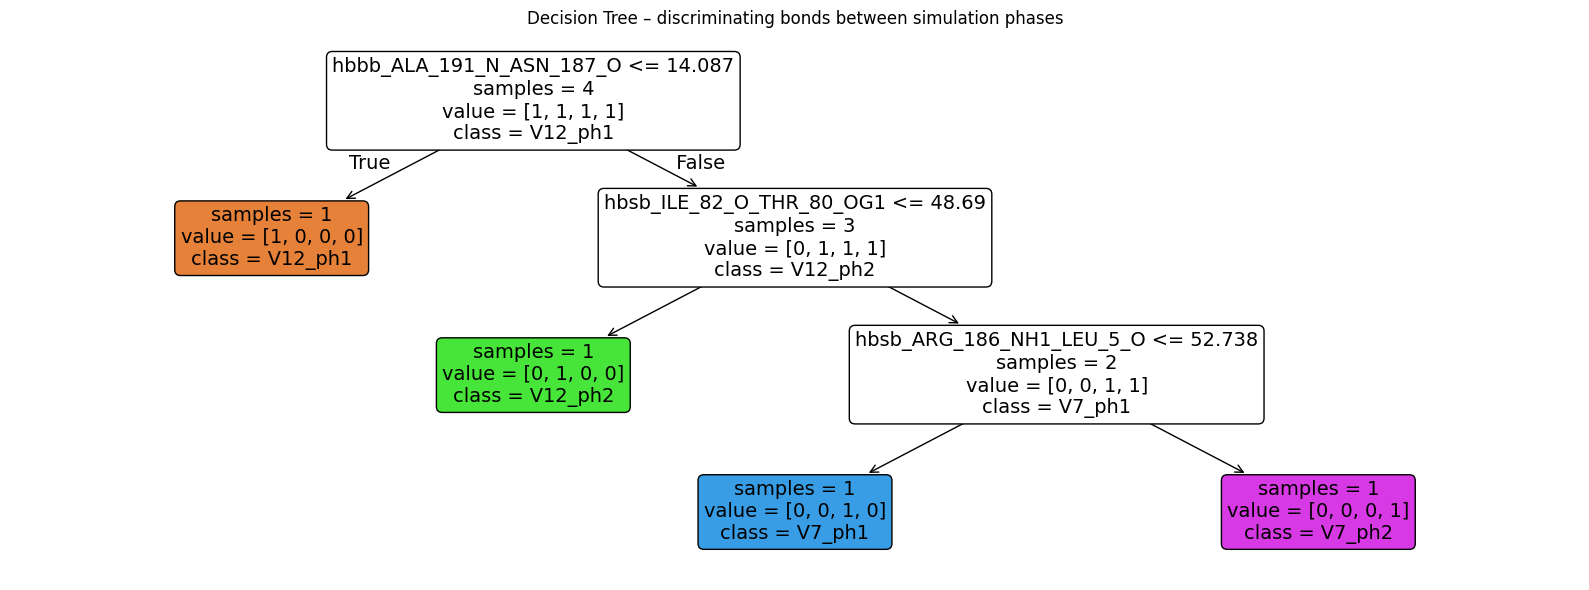

Top 10 discriminating bonds:
hbsb_ILE_82_O_THR_80_OG1        0.333333
hbsb_ARG_186_NH1_LEU_5_O        0.333333
hbbb_ALA_191_N_ASN_187_O        0.333333
hbsb_GLY_138_O_TYR_158_OH       0.000000
hbbb_ILE_82_N_THR_80_O          0.000000
hbbb_ASN_40_O_TYR_42_N          0.000000
hbsb_ASP_25_OD1_GLY_126_N       0.000000
hbss_GLU_136_OE2_THR_176_OG1    0.000000
hbss_ARG_87_NH2_ASP_29_OD2      0.000000
hbsb_ALA_28_N_ASP_25_OD2        0.000000
dtype: float64


In [57]:
# 7. Decision Tree on frequency table
if len(hv_freq) >= 2:
    X_dt = hv_freq.T
    y_dt = X_dt.index.tolist()
    clf  = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(X_dt, y_dt)

    fig, ax = plt.subplots(figsize=(16, 6))
    plot_tree(clf, feature_names=X_dt.columns.tolist(),
              class_names=y_dt, filled=True, rounded=True,
              impurity=False, proportion=False, ax=ax)
    ax.set_title('Decision Tree – discriminating bonds between simulation phases')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=300, bbox_inches='tight')
    plt.show()

    importances = pd.Series(clf.feature_importances_, index=X_dt.columns)
    print('Top 10 discriminating bonds:')
    print(importances.sort_values(ascending=False).head(10))

Intra-chain A bonds : 324
Intra-chain B bonds : 193
Inter-chain A↔B    : 175


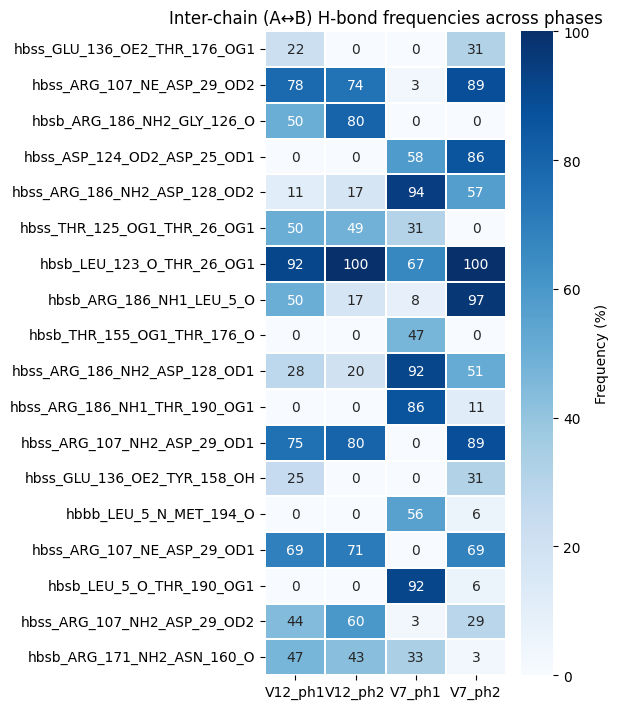

In [58]:
# 8. Inter-chain bond analysis
interchain_mask = pd.Series({b: is_interchain(b) for b in freq_table.index})
intraA_mask = pd.Series({
    b: (classify_chain(get_residue_numbers(b)[0]) == 'A' and
        classify_chain(get_residue_numbers(b)[1]) == 'A')
    for b in freq_table.index})
intraB_mask = pd.Series({
    b: (classify_chain(get_residue_numbers(b)[0]) == 'B' and
        classify_chain(get_residue_numbers(b)[1]) == 'B')
    for b in freq_table.index})

freq_interchain = freq_table[interchain_mask]
freq_intraA     = freq_table[intraA_mask]
freq_intraB     = freq_table[intraB_mask]

print(f'Intra-chain A bonds : {len(freq_intraA)}')
print(f'Intra-chain B bonds : {len(freq_intraB)}')
print(f'Inter-chain A↔B    : {len(freq_interchain)}')

if not freq_interchain.empty:
    ic_hv = high_variance_bonds(freq_interchain, min_delta=MIN_DELTA_PCT)
    if ic_hv.empty:
        ic_hv = freq_interchain

    fig, ax = plt.subplots(figsize=(max(6, len(ic_hv.columns) * 1.5),
                                    max(4, len(ic_hv) * 0.4)))
    sns.heatmap(ic_hv, annot=True, fmt='.0f', cmap='Blues',
                linewidths=0.3, cbar_kws={'label': 'Frequency (%)'}, ax=ax)
    ax.set_title('Inter-chain (A↔B) H-bond frequencies across phases')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'heatmap_interchain.png'), dpi=300, bbox_inches='tight')
    plt.show()